In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:

from sklearn.datasets import load_diabetes

data=load_diabetes()

In [4]:
X=data.data
y=data.target

In [5]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=45)

In [6]:

from sklearn.linear_model import LinearRegression
L=LinearRegression()

In [8]:
L.fit(X_train,y_train)

LinearRegression()

In [10]:
y_pred=L.predict(X_train)

In [12]:
L.score(X_train,y_train)

0.5159857758740993

In [13]:
print(L.coef_)
print(L.intercept_)

[  23.45465406 -247.42747406  492.1087518   329.35876431 -970.79723039
  573.54295519  182.42162368  255.92168168  794.21609282   89.32249214]
152.13623331746496


In [17]:
from sklearn.metrics import r2_score , root_mean_squared_error
r2_score(y_train,y_pred)

0.5159857758740993

In [18]:
root_mean_squared_error(y_train,y_pred)

54.69390610670801

In [50]:
y_pred=L.predict(X_test)

In [21]:
print(r2_score(y_test,y_pred))
print(root_mean_squared_error(y_test,y_pred))

0.5188113124539249
48.72713760953252


## r2_score equal for both train and test but RMSE is less in test dataset

# Ridge Regression

In [70]:
from sklearn.linear_model import Ridge
rr=Ridge(alpha=10)
rr.fit(X_train,y_train)

Ridge(alpha=10)

In [66]:
print(rr.coef_)
print(rr.intercept_)

[ 18.77788374   0.36423186  64.21521328  49.17553459  14.4397287
   9.62339853 -40.53928043  39.32153888  59.20162298  40.36525253]
151.96368446414732


In [67]:
y_pred=rr.predict(X_test)

In [68]:
print(r2_score(y_test,y_pred))
print(root_mean_squared_error(y_test,y_pred))

0.18324524136176967
63.48323251986342


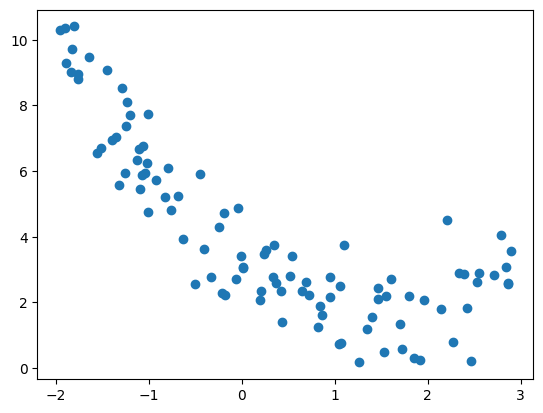

In [51]:
m = 100
x1 = 5 * np.random.rand(m, 1) - 2
x2 = 0.7 * x1 ** 2 - 2 * x1 + 3 + np.random.randn(m, 1)

plt.scatter(x1, x2)
plt.show()

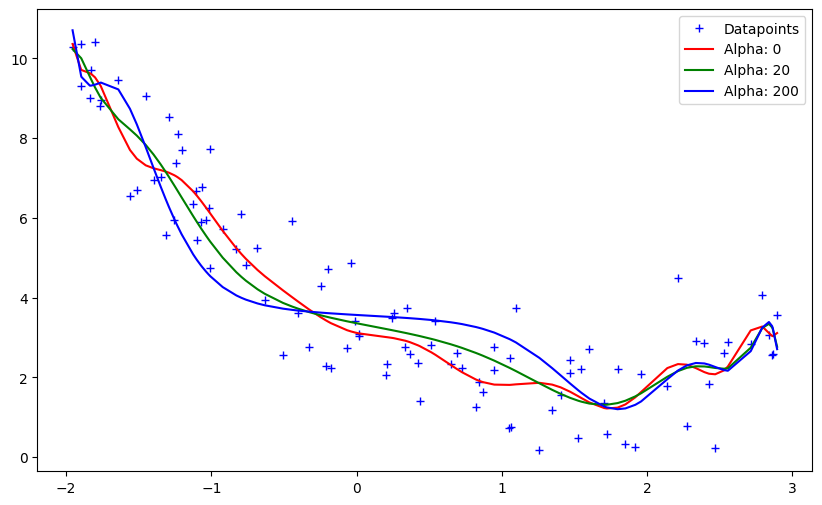

In [52]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

def get_preds_ridge(x1, x2, alpha):
    model = Pipeline([
        ('poly_feats', PolynomialFeatures(degree=16)),
        ('ridge', Ridge(alpha=alpha))
    ])
    model.fit(x1, x2)
    return model.predict(x1)

alphas = [0, 20, 200]
cs = ['r', 'g', 'b']

plt.figure(figsize=(10, 6))
plt.plot(x1, x2, 'b+', label='Datapoints')

for alpha, c in zip(alphas, cs):
    preds = get_preds_ridge(x1, x2, alpha)
    # Plot
    plt.plot(sorted(x1[:, 0]), preds[np.argsort(x1[:, 0])], c, label='Alpha: {}'.format(alpha))

plt.legend()
plt.show()